# Практика: Снижение размерности — PCA, t-SNE и UMAP

## Что вы сделаете
В этом ноутбуке вы:

1. загрузите и исследуете датасет `digits` (рукописные цифры);
2. примените **PCA** как препроцессинг: выберете число компонент по cumulative EVR;
3. проинтерпретируете главные компоненты через **loadings**;
4. обучите классификатор на PCA-признаках и сравните с обучением на исходных признаках;
5. визуализируете структуру данных через **t-SNE** и **UMAP**;
6. сравните 2D-проекции PCA, t-SNE и UMAP: насколько хорошо разделяются классы?

## Датасет
Мы используем `digits` из `sklearn.datasets`:
- 1797 изображений рукописных цифр 0–9;
- каждое изображение — 8×8 пикселей = **64 признака** (интенсивность пикселей);
- задача: 10-классовая классификация.

## Что сдавать
1. Заполненный ноутбук со всем кодом.
2. Краткие выводы в конце:
   - сколько компонент PCA достаточно для сохранения 95% дисперсии?
   - как влияет PCA-препроцессинг на качество классификатора?
   - какой метод визуализации (PCA, t-SNE, UMAP) лучше разделяет классы?

---
## Шаг 1. Загрузка и первичный анализ данных

In [1]:
import numpy as np
import sklearn
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import load_digits
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

digits = load_digits()
X = digits.data
y = digits.target

print(f"Форма X: {X.shape}")
print(f"Классы: {np.unique(y)}")
print(f"Признаки: {X.shape[1]} (8x8 пикселей)")

Форма X: (1797, 64)
Классы: [0 1 2 3 4 5 6 7 8 9]
Признаки: 64 (8x8 пикселей)


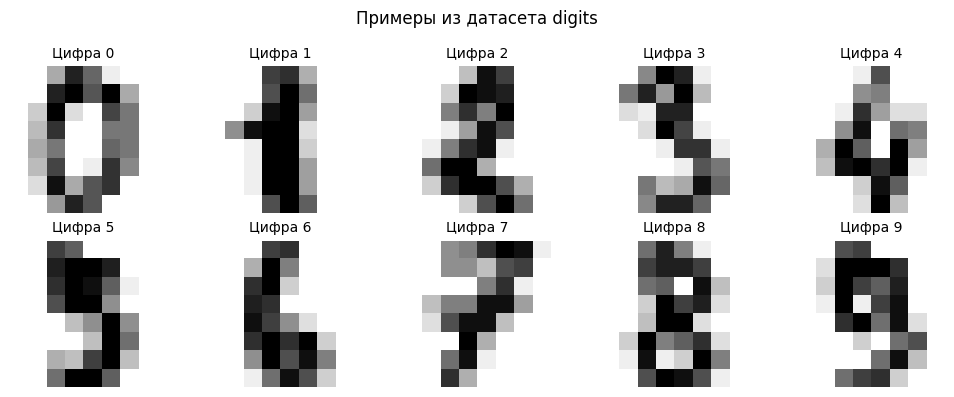

In [3]:
# Визуализируем примеры из каждого класса
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for ax, idx in zip(axes.flat, range(10)):
    sample_idx = np.where(y == idx)[0][0]
    ax.imshow(X[sample_idx].reshape(8, 8), cmap='gray_r')
    ax.set_title(f'Цифра {idx}', fontsize=10)
    ax.axis('off')
plt.suptitle('Примеры из датасета digits', fontsize=12)
plt.tight_layout()
plt.show()

In [5]:
# Стандартизация — обязательный шаг перед PCA!
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Среднее до: {X.mean():.2f}, после: {X_scaled.mean():.4f}")
print(f"Std до: {X.std():.2f}, после: {X_scaled.std():.4f}")

Среднее до: 4.88, после: 0.0000
Std до: 6.02, после: 0.9763


---
## Шаг 2. PCA: explained variance и выбор числа компонент

Обучите PCA на всех 64 компонентах. Постройте график накопленной объясняемой дисперсии.
Определите, сколько компонент нужно для сохранения 80%, 95% и 99% дисперсии.

80% дисперсии -> 21 компонент
95% дисперсии -> 40 компонент
99% дисперсии -> 54 компонент


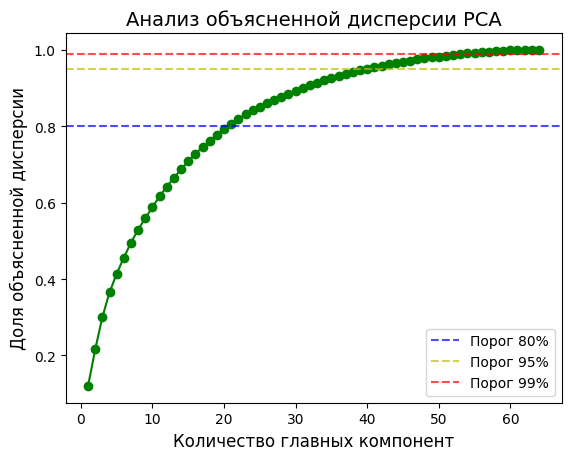

In [7]:
# Обучите PCA на всех компонентах
pca_full = PCA(n_components=64, random_state=42)
# YOUR CODE HERE
pca_full.fit(X_scaled)

# Вычислите накопленную объясняемую дисперсию
cumvar = np.cumsum(pca_full.explained_variance_ratio_)

# Постройте график: по оси X — число компонент, по оси Y — cumvar
# Добавьте горизонтальные линии для 80%, 95%, 99%
# YOUR CODE HERE
plt.plot(
    np.arange(1, len(cumvar) + 1),
    cumvar,
    marker='o',
    color='g'
)
plt.axhline(0.8, linestyle='--', color='b', alpha=0.7, label='Порог 80%')
plt.axhline(0.95, linestyle='--', color='y', alpha=0.7, label='Порог 95%')
plt.axhline(0.99, linestyle='--', color='r', alpha=0.7, label='Порог 99%')
plt.title('Анализ объясненной дисперсии PCA', fontsize=14)
plt.xlabel('Количество главных компонент', fontsize=12)
plt.ylabel('Доля объясненной дисперсии', fontsize=12)
plt.legend()

# Найдите минимальное k для каждого порога
for threshold in [0.80, 0.95, 0.99]:
    k = np.where(cumvar >= threshold)[0][0] + 1
    print(f"{int(threshold*100)}% дисперсии -> {k} компонент")

---
## Шаг 3. PCA для визуализации (2 компоненты)

Спроецируйте данные на 2 главных компоненты. Визуализируйте scatter plot с раскраской по классу.
Укажите долю объяснённой дисперсии на осях.

PC1: 12.0%
PC2: 9.6%
Итого: 21.6%


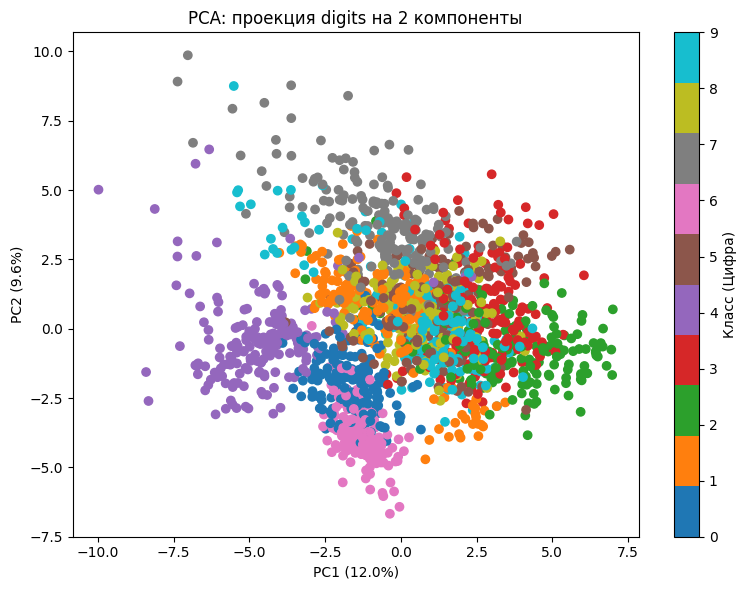

In [9]:
pca2 = PCA(n_components=2, random_state=42)
X_pca2 = pca2.fit_transform(X_scaled)# YOUR CODE HERE

print(f"PC1: {pca2.explained_variance_ratio_[0]*100:.1f}%")
print(f"PC2: {pca2.explained_variance_ratio_[1]*100:.1f}%")
print(f"Итого: {pca2.explained_variance_ratio_.sum()*100:.1f}%")

plt.figure(figsize=(8, 6))
# YOUR CODE HERE: scatter с cmap='tab10', colorbar
scatter = plt.scatter(X_pca2[:, 0], X_pca2[:, 1], c=y, cmap='tab10')
plt.colorbar(scatter, label='Класс (Цифра)')

plt.xlabel(f'PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}%)')
plt.title('PCA: проекция digits на 2 компоненты')
plt.tight_layout()
plt.show()

---
## Шаг 4. Интерпретация: loadings (нагрузки)

Visualizируйте нагрузки PC1 и PC2 как 8×8 изображения.
Яркие пиксели = сильное влияние на данную компоненту.
Используйте diverging colormap `'RdBu_r'`.

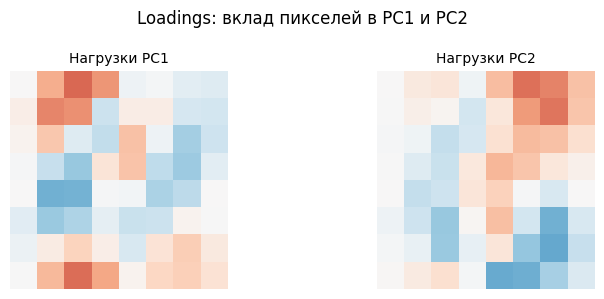

In [13]:
# pca2.components_ имеет форму (2, 64)
fig, axes = plt.subplots(1, 2, figsize=(8, 3))
for i, ax in enumerate(axes):
    # YOUR CODE HERE
    # Подсказка: pca2.components_[i].reshape(8, 8)
    ax.imshow(pca2.components_[i].reshape(8, 8), cmap='RdBu_r', vmin=-0.5, vmax=0.5)
    ax.set_title(f'Нагрузки PC{i+1}', fontsize=10)
    ax.axis('off')

plt.suptitle('Loadings: вклад пикселей в PC1 и PC2', fontsize=12)
plt.tight_layout()
plt.show()

# Вопрос: какие области изображения наиболее важны для PC1 и PC2?

Более всего важны области, которые выделяются ярче всего. Например (4-5 ряд 2 -3 столбцы, 1-2 ряд 2-3 столбцы, 1- 2 ряд 6-7 столбцы и так далее)

---
## Шаг 5. PCA как препроцессинг для классификатора

Сравните качество LogisticRegression:
1. На исходных 64 признаках
2. На PCA 95% дисперсии
3. На PCA 80% дисперсии

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

results = {}

# --- Вариант 1: без PCA ---
clf_base = LogisticRegression(max_iter=1000, random_state=42)
# YOUR CODE HERE
clf_base.fit(X_train, y_train)
y_pred_base = clf_base.predict(X_test)
results['Без PCA (64 признака)'] = accuracy_score(y_test, y_pred_base) # YOUR CODE HERE

# --- Вариант 2: PCA с 95% дисперсии ---
# Подсказка: PCA(n_components=0.95) автоматически выбирает k
pca_95 = PCA(n_components=0.95, random_state=42)
X_train_95 = pca_95.fit_transform(X_train)
X_test_95  = pca_95.transform(X_test)
clf_95 = LogisticRegression(max_iter=1000, random_state=42)
# YOUR CODE HERE
clf_95.fit(X_train_95, y_train)
y_pred_95 = clf_95.predict(X_test_95)
results[f'PCA 95% ({pca_95.n_components_} компонент)'] = accuracy_score(y_test, y_pred_95)# YOUR CODE HERE

# --- Вариант 3: PCA с 80% дисперсии ---
pca_80 = PCA(n_components=0.80, random_state=42)
# YOUR CODE HERE
X_train_80 = pca_80.fit_transform(X_train)
X_test_80 = pca_80.transform(X_test)
clf_80 = LogisticRegression(max_iter=1000, random_state=42)
clf_80.fit(X_train_80, y_train)
y_pred_80 = clf_80.predict(X_test_80)
results[f'PCA 80% ({pca_80.n_components_} компонент)'] = accuracy_score(y_test, y_pred_80)# YOUR CODE HERE

print("Сравнение accuracy:")
print("-" * 45)
for name, acc in results.items():
    print(f"{name:35s}: {acc:.4f}")

Сравнение accuracy:
---------------------------------------------
Без PCA (64 признака)              : 0.9722
PCA 95% (40 компонент)             : 0.9639
PCA 80% (21 компонент)             : 0.9472


---
## Шаг 6. t-SNE: нелинейная визуализация

Рекомендуемый пайплайн: сначала PCA до 30 компонент, затем t-SNE. Это ускоряет работу и убирает шум.

После PCA(30): 89.3% дисперсии


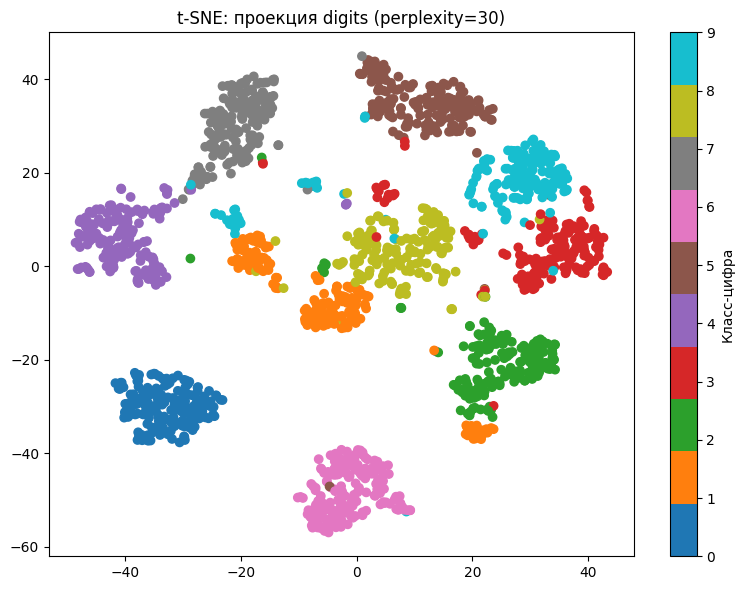

In [17]:
# PCA до 30 компонент (препроцессинг перед t-SNE)
pca_30 = PCA(n_components=30, random_state=42)
X_pca30 = pca_30.fit_transform(X_scaled)
print(f"После PCA(30): {pca_30.explained_variance_ratio_.sum()*100:.1f}% дисперсии")

# t-SNE
tsne = TSNE(n_components=2, perplexity=30, n_iter=1000, random_state=42)
X_tsne = tsne.fit_transform(X_pca30)# YOUR CODE HERE

plt.figure(figsize=(8, 6))
# YOUR CODE HERE: scatter с cmap='tab10'
scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y, cmap='tab10')
plt.colorbar(scatter, label='Класс-цифра')
plt.title('t-SNE: проекция digits (perplexity=30)')
plt.tight_layout()
plt.show()

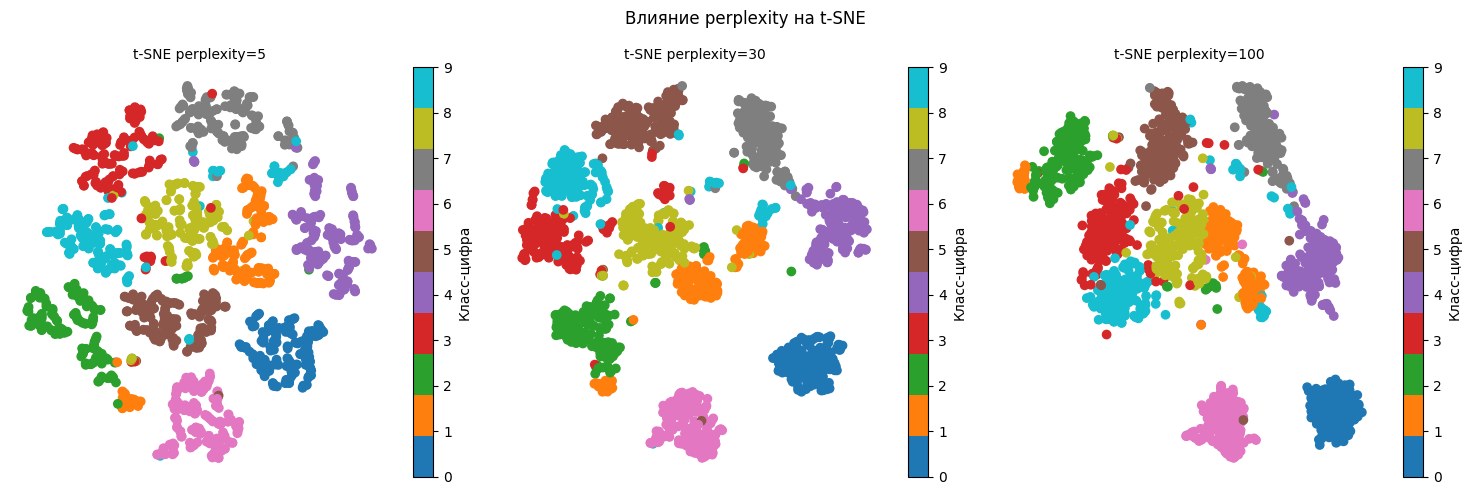

In [49]:
# Эксперимент с perplexity: 5, 30, 100
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, perp in zip(axes, [5, 30, 100]):
    tsne_p = TSNE(n_components=2, perplexity=perp, n_iter=1000, random_state=42)
    # YOUR CODE HERE: fit_transform и scatter
    X_tsne_perp = tsne_p.fit_transform(X_pca30)
    scatter = ax.scatter(X_tsne_perp[:, 0], X_tsne_perp[:, 1], c=y, cmap='tab10')
    cbar = fig.colorbar(scatter, ax=ax, label = "Класс-цифра")
    ax.set_title(f't-SNE perplexity={perp}', fontsize=10)
    ax.axis('off')

plt.suptitle('Влияние perplexity на t-SNE', fontsize=12)
plt.tight_layout()
plt.show()

---
## Шаг 7. UMAP

Если не установлен: `pip install umap-learn`

In [21]:
!pip install umap-learn


[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [19]:
!pip install "scikit-learn<1.6"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.3/13.3 MB 80.1 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.8.0
    Uninstalling scikit-learn-1.8.0:
      Successfully uninstalled scikit-learn-1.8.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
umap-learn 0.5.12 requires scikit-learn>=1.6, but you have scikit-learn 1.5.2 which is incompatible.

[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [23]:
# Форсированно подменяем ожидаемый аргумент во внутренней кухне sklearn
if not hasattr(sklearn.utils, 'check_array'):
    from sklearn.utils import validation
    # Если функция лежит в подмодуле validation
    orig_check_array = validation.check_array
    def patched_check_array(*args, **kwargs):
        if 'ensure_all_finite' in kwargs:
            kwargs['force_all_finite'] = kwargs.pop('ensure_all_finite')
        return orig_check_array(*args, **kwargs)
    validation.check_array = patched_check_array
else:
    orig_check_array = sklearn.utils.check_array
    def patched_check_array(*args, **kwargs):
        if 'ensure_all_finite' in kwargs:
            # Перенаправляем новое имя в старое
            kwargs['force_all_finite'] = kwargs.pop('ensure_all_finite')
        return orig_check_array(*args, **kwargs)
    sklearn.utils.check_array = patched_check_array

2026-05-29 10:20:39.686489: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780050039.704738      81 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780050039.710317      81 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780050039.725439      81 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780050039.725466      81 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780050039.725469      81 computation_placer.cc:177] computation placer alr

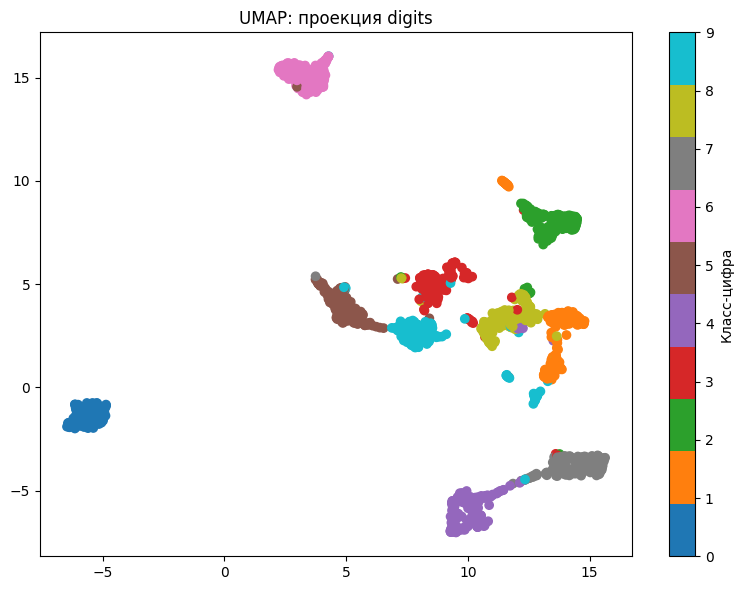

In [25]:
try:
    import umap
    UMAP_AVAILABLE = True
    print("umap-learn доступен")
except ImportError:
    print("Установите: pip install umap-learn")
    UMAP_AVAILABLE = False

if UMAP_AVAILABLE:
    reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
    X_umap = reducer.fit_transform(X_pca30)# YOUR CODE HERE

    plt.figure(figsize=(8, 6))
    # YOUR CODE HERE: scatter
    scatter = plt.scatter(X_umap[:, 0], X_umap[:, 1], c=y, cmap='tab10')
    plt.colorbar(scatter, label='Класс-цифра')
    plt.title('UMAP: проекция digits')
    plt.tight_layout()
    plt.show()

---
## Шаг 8. Сравнение проекций: PCA vs t-SNE vs UMAP

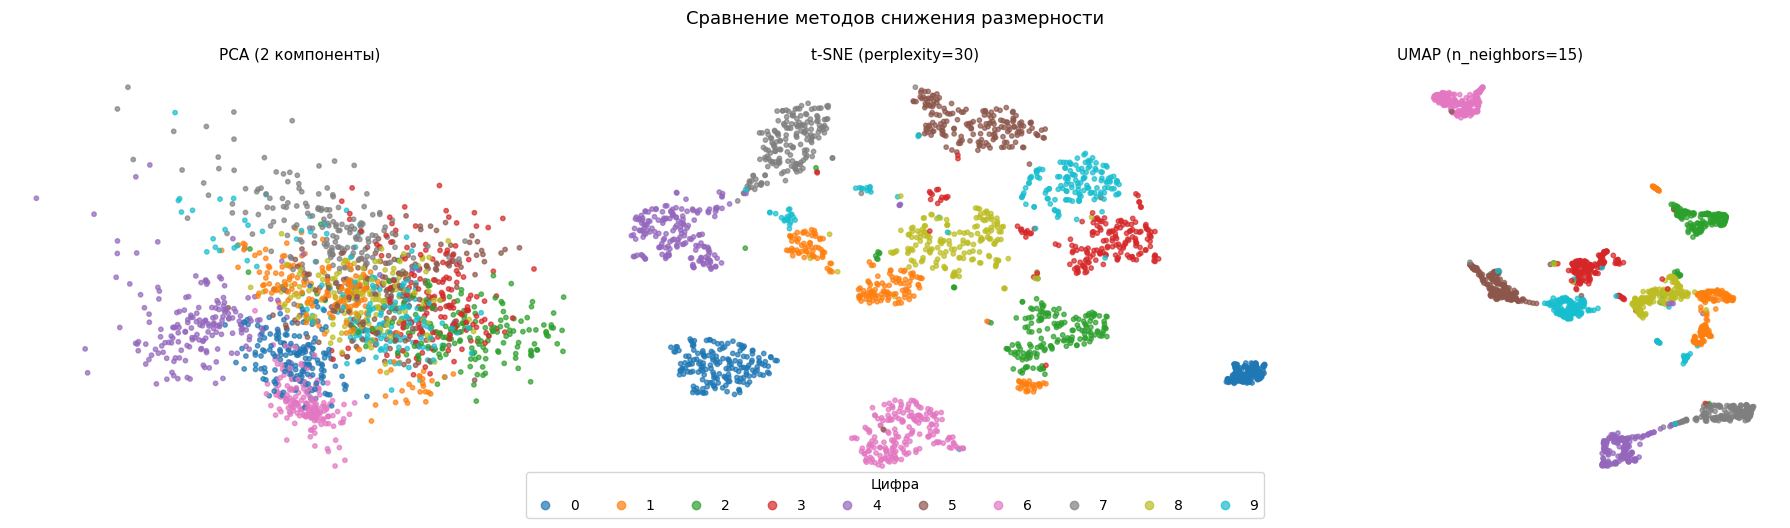

In [27]:
n_plots = 3 if UMAP_AVAILABLE else 2
fig, axes = plt.subplots(1, n_plots, figsize=(6*n_plots, 5))

projections = [
    (X_pca2, 'PCA (2 компоненты)'),
    (X_tsne, 't-SNE (perplexity=30)'),
]
if UMAP_AVAILABLE:
    projections.append((X_umap, 'UMAP (n_neighbors=15)'))

for ax, (X_proj, title) in zip(axes, projections):
    scatter = ax.scatter(X_proj[:, 0], X_proj[:, 1],
                         c=y, cmap='tab10', s=10, alpha=0.7)
    ax.set_title(title, fontsize=11)
    ax.axis('off')

handles, _ = scatter.legend_elements()
fig.legend(handles, [str(i) for i in range(10)],
           loc='lower center', ncol=10, title='Цифра',
           bbox_to_anchor=(0.5, -0.05))
plt.suptitle('Сравнение методов снижения размерности', fontsize=13)
plt.tight_layout()
plt.show()

---
## Шаг 9. Количественная оценка: Silhouette Score

In [31]:
from sklearn.metrics import silhouette_score

scores = {}
scores['PCA (2 компоненты)'] = silhouette_score(X_pca2, y)
scores['t-SNE']               = silhouette_score(X_tsne, y)# YOUR CODE HERE
if UMAP_AVAILABLE:
    scores['UMAP']            = silhouette_score(X_umap, y)# YOUR CODE HERE

print("Silhouette Score (выше = лучше):")
print("-" * 35)
for name, score in sorted(scores.items(), key=lambda x: -x[1]):
    print(f"{name:25s}: {score:.4f}")

Silhouette Score (выше = лучше):
-----------------------------------
UMAP                     : 0.5917
t-SNE                    : 0.4858
PCA (2 компоненты)       : 0.0547


---
## Шаг 10. Реконструкция из PCA

PCA позволяет восстановить исходные данные через `inverse_transform`. Посмотрим, как выглядит реконструкция при разном числе компонент.

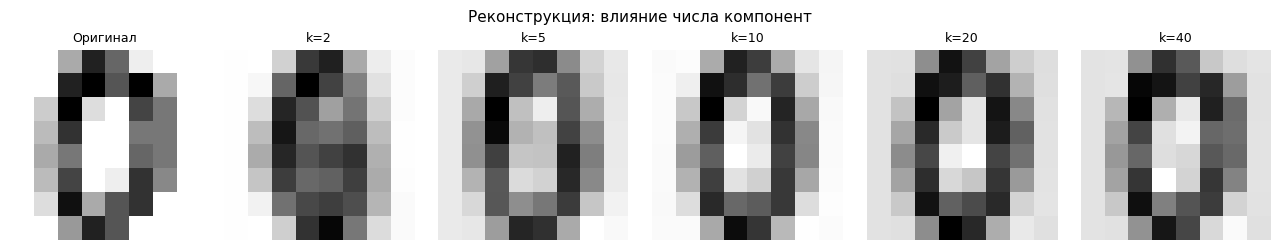

In [39]:
sample_idx = 0
x_original = X_scaled[sample_idx:sample_idx+1]

fig, axes = plt.subplots(1, 6, figsize=(13, 2.5))

# Оригинал
axes[0].imshow(scaler.inverse_transform(x_original).reshape(8, 8), cmap='gray_r')
axes[0].set_title('Оригинал', fontsize=9)
axes[0].axis('off')

for ax, k in zip(axes[1:], [2, 5, 10, 20, 40]):
    pca_k = PCA(n_components=k, random_state=42)
    pca_k.fit(X_scaled)
    # YOUR CODE HERE:
    # 1. Спроецируйте x_original: x_proj = pca_k.transform(x_original)
    # 2. Восстановите: x_rec = pca_k.inverse_transform(x_proj)
    # 3. Обратите стандартизацию: scaler.inverse_transform(x_rec)
    # 4. Отобразите как 8x8 изображение
    X_proj = pca_k.transform(x_original)
    X_rec = pca_k.inverse_transform(X_proj)
    X_rec_no_scaler = scaler.inverse_transform(X_rec)
    ax.imshow(X_rec_no_scaler.reshape(8, 8),  cmap='gray_r')
    ax.set_title(f'k={k}', fontsize=9)
    ax.axis('off')

plt.suptitle('Реконструкция: влияние числа компонент', fontsize=11)
plt.tight_layout()
plt.show()

---
## Выводы

### Ваши выводы

**1. Число компонент PCA:**
- Для сохранения 80% дисперсии нужно 21 компонент из 64.
- Для сохранения 95% дисперсии нужно 40 компонент из 64.

**2. PCA как препроцессинг:**
- Accuracy без PCA: 0.9722
- Accuracy с PCA (95%): 0.9639
- Accuracy с PCA (80%): 0.9472
- Вывод: _(PCA помогает / не влияет / снижает качество — и почему?)
Как можно видеть, чем меньше сохранение дисперсии, тем меньше качество. С другой стороны, снижение может быть незначительное, как например происходит у нас. В нашем случае ситуация достаточно легкая. Логистическая регрессия и так с достаточной скоростью обучается, и без переобучения. Но если у нас около 1000 признаков, модель может переобучиться. Если особенно в признаках есть шум, PCA может сильно помочь

**3. Сравнение проекций:**
- Лучший Silhouette Score: 0.5917 (метод: UMAP)
- Цифры, которые сложнее всего разделить: 9, 3, 1, (может ещё 4 и 7)

**4. Вывод о методах:**
- _Когда применять PCA, а когда t-SNE/UMAP?_
PCA стоит применять когда важно иметь обратное преобразование, когда задача стоит именно в урезании признаков, уменьшение шумов, для интерпретируемости. А t-sne и UMAP созданы чисто для визуализации, они не предполагают создание новых признаков, у них нету обратного преобразования. Эти два метода служат для разведки данных, чтобы понять, какие данные стоят вместе, какие раздельно и тд.

## Маленькие эксперименты постфактум

### Эксперимент 1. Поведение PCA при большом количестве шумовых признаков

Урежу случайным образом выборку так, чтобы количество новых признаков было намного больше объектов

In [41]:
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
import numpy as np

rng = np.random.RandomState(42)

digits = load_digits()
X_full, y_full = digits.data, digits.target

# 1) урезаем до 500 объектов
idx = rng.choice(len(X_full), size=500, replace=False)
X_small = X_full[idx]
y_small = y_full[idx]

# 2) добавляем 1500 шумовых признаков -> ~3x больше признаков, чем объектов
noise = rng.normal(0, 1, size=(X_small.shape[0], 1500))
X_noisy = np.hstack([X_small, noise])   # 64 реальных + 1500 шум = 1564 признака

print(f"Объектов: {X_noisy.shape[0]}, признаков: {X_noisy.shape[1]} (64 реальных + 1500 шум)")

X_train_1, X_test_1, y_train1, y_test_1 = train_test_split(
    X_noisy, y_small, test_size=0.3, random_state=42, stratify=y_small
)
print(f"train: {X_train_1.shape}, test: {X_test_1.shape}")

Объектов: 500, признаков: 1564 (64 реальных + 1500 шум)
train: (350, 1564), test: (150, 1564)


In [47]:
from sklearn.pipeline import Pipeline

pipe_1 = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000, random_state=42))
])
pipe_1.fit(X_train_1, y_train1)
print('Метрика на зашумленном датасете')
print(f'accuracy = {accuracy_score(y_test_1, pipe_1.predict(X_test_1))}')

Метрика на зашумленном датасете
accuracy = 0.6266666666666667


Теперь продемонстрируем, что сделает с этим PCA. Но для начала посмотрим прирост дисперсии

80% дисперсии -> 165 компонент
95% дисперсии -> 281 компонент
99% дисперсии -> 332 компонент


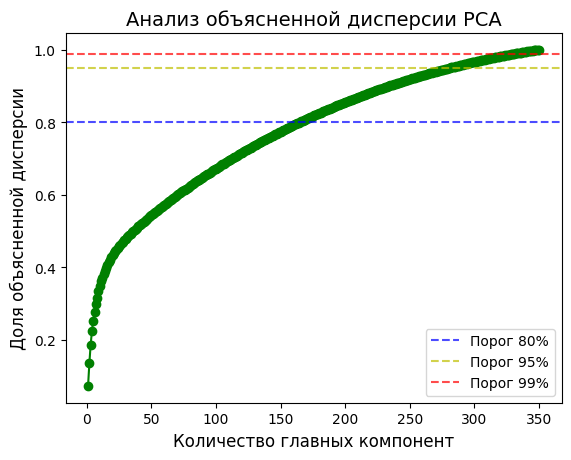

In [57]:
pca_1 = PCA(  random_state=42)
X_train_pca_1 = pca_1.fit_transform(X_train_1)
X_test_pca_1 = pca_1.transform(X_test_1)

cumvar = np.cumsum(pca_1.explained_variance_ratio_)
plt.plot(
    np.arange(1, len(cumvar) + 1),
    cumvar,
    marker='o',
    color='g'
)
plt.axhline(0.8, linestyle='--', color='b', alpha=0.7, label='Порог 80%')
plt.axhline(0.95, linestyle='--', color='y', alpha=0.7, label='Порог 95%')
plt.axhline(0.99, linestyle='--', color='r', alpha=0.7, label='Порог 99%')
plt.title('Анализ объясненной дисперсии PCA', fontsize=14)
plt.xlabel('Количество главных компонент', fontsize=12)
plt.ylabel('Доля объясненной дисперсии', fontsize=12)
plt.legend()

# Найдите минимальное k для каждого порога
for threshold in [0.80, 0.95, 0.99]:
    k = np.where(cumvar >= threshold)[0][0] + 1
    print(f"{int(threshold*100)}% дисперсии -> {k} компонент")

In [65]:
for n in [10, 20, 30, 34, 35, 36, 37,  40, 50, 60, 100, 270 ]:
    pca_1 = PCA(n_components=n, random_state=42)
    X_train_pca_1 = pca_1.fit_transform(X_train_1)
    X_test_pca_1 = pca_1.transform(X_test_1)
    pipe_1.fit(X_train_pca_1, y_train1)
    print(f'Для числа компонент {n}: accuracy = {accuracy_score(y_test_1, pipe_1.predict(X_test_pca_1))}')

Для числа компонент 10: accuracy = 0.9066666666666666
Для числа компонент 20: accuracy = 0.94
Для числа компонент 30: accuracy = 0.96
Для числа компонент 34: accuracy = 0.96
Для числа компонент 35: accuracy = 0.9666666666666667
Для числа компонент 36: accuracy = 0.96
Для числа компонент 37: accuracy = 0.9466666666666667
Для числа компонент 40: accuracy = 0.9533333333333334
Для числа компонент 50: accuracy = 0.9533333333333334
Для числа компонент 60: accuracy = 0.9266666666666666
Для числа компонент 100: accuracy = 0.92
Для числа компонент 270: accuracy = 0.86


Как можно видеть, ситуация складывается интересная. Несмотря на то, что у нас отсеяно большое количество дисперсии, тем не менее большинство из этой дисперсии - шум. Поэтому график улучшения тут дугообразныыый. При числе компонент меньше 30 много отсеивается полезной информации, хотя и на этом этапе, наблюдается достаточное улучшение метрики, по сравнению c изначальным зашумленным датасетом. На 35 компонентах даже подошло близко к метрике с незашумелнным датасетом, которая получена в основной части домашки. Но это сработало, потому что шум в основном одного масштаба и он независимый. ВНизу показано, что было бы, если признаки скоррелированы, то PCA1 будет выделяться, тогда как при независимости все направления почти одинаковы. Количество компонент надо выбирать по метрике, а не по дисперсии. 

<img src="image-20260529-135101.png" width="" align="" />